In [91]:
import numpy as np
import matplotlib.pyplot as plt

In [92]:
def vrow(x):
    """Convert a vector to a row vector"""
    return x.reshape(1, -1)

In [93]:
def vcol(x):
    """Convert a vector to a column vector"""
    return x.reshape(-1, 1)

In [94]:
def logpdf_GAU_ND(X, mu, C):
    """
    Compute the log-density for a multivariate Gaussian distribution.

    Parameters:
    X: a matrix of shape (M, N) containing N samples of dimension M
    mu: a column vector of shape (M, 1) representing the mean
    C: a matrix of shape (M, M) representing the covariance matrix

    Returns:
    A vector of shape (N,) containing the log-densities for each sample
    """
    M = X.shape[0] # Feature dimension

    # Compute the inverse of the covariance matrix
    C_inv = np.linalg.inv(C)

    # Compute the log-determinant of the covariance matrix
    sign, log_det_C = np.linalg.slogdet(C)

    # Compute the constant term
    const = -M/2 * np.log(2*np.pi) - 0.5 * log_det_C

    # Initialize the array of log-densities
    N = X.shape[1] # Number of samples
    log_densities = np.zeros(N)

    # For each sample, compute the log-density
    for i in range(N):
        x_i = X[:, i:i+1] # Extract the i-th sample
        centered_x = x_i - mu # Center the sample
        quad_form = np.dot(np.dot(centered_x.T, C_inv), centered_x) # Compute the quadratic form
        log_densities[i] = const - 0.5 * quad_form.item()

    return log_densities

In [95]:
def logpdf_GAU_ND_vectorized(X, mu, C):
    """
    Compute the log-density for a multivariate Gaussian distribution using vectorized operations.

    Parameters:
    X: a matrix of shape (M, N) containing N samples of dimension M
    mu: a column vector of shape (M, 1) representing the mean
    C: a matrix of shape (M, M) representing the covariance matrix

    Returns:
    A vector of shape (N,) containing the log-densities for each sample
    """
    M = X.shape[0] # Feature dimension

    # Compute the inverse of the covariance matrix
    C_inv = np.linalg.inv(C)

    # Compute the log-determinant of the covariance matrix
    sign, log_det_C = np.linalg.slogdet(C)

    # Compute the constant term
    const = -M/2 * np.log(2*np.pi) - 0.5 * log_det_C

    # Center the data matrix
    centered_X = X - mu

    # Compute the quadratic forms of all samples at once
    Y = np.dot(C_inv, centered_X)

    # Then, compute (x-μ)ᵀΣ⁻¹(x-μ) for all samples# This is done by element-wise multiplying centered_X and Y, and summing over rows
    quad_forms = np.sum(centered_X * Y, axis=0)

    # Compute the log
    log_densities = const - 0.5 * quad_forms

    return log_densities

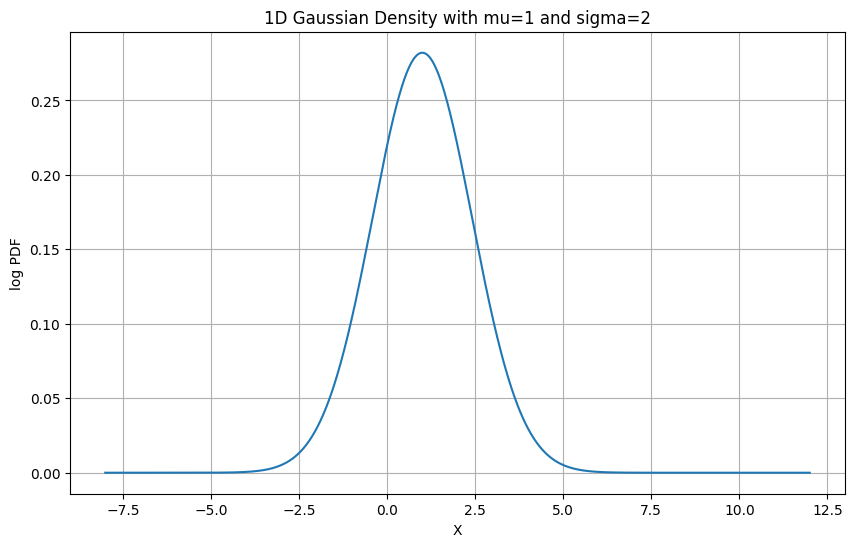

In [96]:
# Example 1: 1D Gaussina with mu=1, sigma=2
plt.figure(figsize=(10, 6))
XPlot = np.linspace(-8, 12, 1000)
m = np.ones((1, 1)) * 1.0
C = np.ones((1, 1)) * 2.0
plt.plot(XPlot.ravel(), np.exp(logpdf_GAU_ND(vrow(XPlot), m, C)))
plt.title('1D Gaussian Density with mu=1 and sigma=2')
plt.xlabel('X')
plt.ylabel('log PDF')
plt.grid(True)
plt.show()

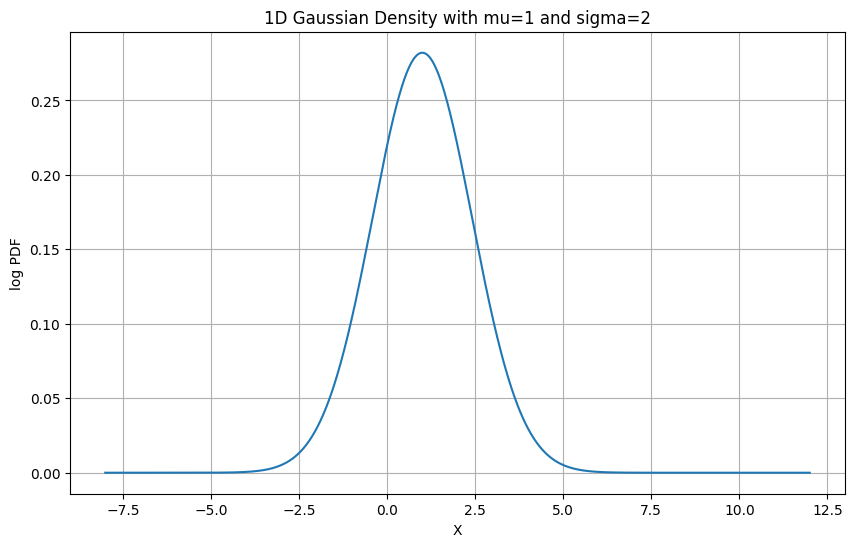

In [97]:
# Example 2: 1D Gaussina with mu=1, sigma=2
plt.figure(figsize=(10, 6))
XPlot = np.linspace(-8, 12, 1000)
m = np.ones((1, 1)) * 1.0
C = np.ones((1, 1)) * 2.0
plt.plot(XPlot.ravel(), np.exp(logpdf_GAU_ND_vectorized(vrow(XPlot), m, C)))
plt.title('1D Gaussian Density with mu=1 and sigma=2')
plt.xlabel('X')
plt.ylabel('log PDF')
plt.grid(True)
plt.show()

In [98]:
def compute_empirical_mean(X):
    """
    Compute the empirical mean of a dataset.

    Parameters:
    X: a matrix of shape (M, N) containing N samples of dimension M

    Returns:
    A column vector of shape (M, 1) representing the empirical mean
    """
    return vcol(X.mean(axis=1))

In [99]:
def compute_empirical_covariance(X, mu=None):
    """
    Compute the empirical covariance of a dataset.

    Parameters:
    X: a matrix of shape (M, N) containing N samples of dimension M
    mu: a column vector of shape (M, 1) representing the mean (optional)

    Returns:
    A matrix of shape (M, M) representing the empirical covariance
    """
    if mu is None:
        mu = compute_empirical_mean(X)

    N = X.shape[1]
    centered_X = X - mu
    return (1/N) * np.dot(centered_X, centered_X.T)

In [100]:
def loglikelihood(X, mu, C):
    """
    Compute the log-likelihood of a dataset given a Gaussian model.

    Parameters:
    X: a matrix of shape (M, N) containing N samples of dimension M
    mu: a column vector of shape (M, 1) representing the mean
    C: a matrix of shape (M, M) representing the covariance matrix

    Returns:
    The log-likelihood (a scalar value)
    """
    return np.sum(logpdf_GAU_ND(X, mu, C))

In [101]:
XND = np.load('./Solution/XND.npy')
m_ML = compute_empirical_mean(XND)
C_ML = compute_empirical_covariance(XND, m_ML)

# Print the ML estimates
print("ML mean estimate:")
print(m_ML)
print("\nML covariance estimate:")
print(C_ML)

# Compute the log-likelihood
ll = loglikelihood(XND, m_ML, C_ML)
print(f"\nLog-likelihood of the dataset: {ll}")

ML mean estimate:
[[-0.07187197]
 [ 0.05979594]]

ML covariance estimate:
[[0.94590166 0.09313534]
 [0.09313534 0.8229693 ]]

Log-likelihood of the dataset: -270.70478023795044


ML mean estimate:
[[1.9539157]]

ML covariance estimate:
[[6.09542485]]

Log-likelihood of the dataset: -23227.07765460272


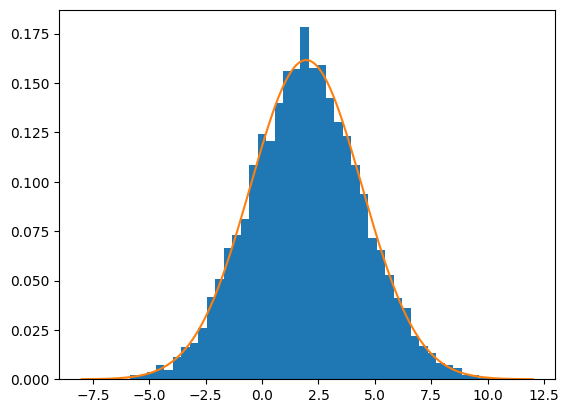

In [102]:
X1D = np.load('./Solution/X1D.npy')
m_ML = compute_empirical_mean(X1D)
C_ML = compute_empirical_covariance(X1D, m_ML)

# Print the ML estimates
print("ML mean estimate:")
print(m_ML)
print("\nML covariance estimate:")
print(C_ML)

# Compute the log-likelihood
ll = loglikelihood(X1D, m_ML, C_ML)
print(f"\nLog-likelihood of the dataset: {ll}")

plt.figure()
plt.hist(X1D.ravel(), bins=50, density=True)
XPlot = np.linspace(-8, 12, 1000)
plt.plot(XPlot.ravel(), np.exp(logpdf_GAU_ND(vrow(XPlot), m_ML, C_ML)))

In [103]:
def fit_and_visualize_gaussian_feature(X, feature_idx, feature_name, class_name):
    """
    Fit a univariate Gaussian model to a specific feature and visualize the results.

    Parameters:
    X: the data matrix where rows are features and columns are samples
    feature_idx: the index of the feature to analyze
    feature_name: name of the feature for plot title
    class_name: name of the class for plot title
    """
    # Extract the specified feature
    feature_values = X[feature_idx:feature_idx+1, :]

    # Compute ML estimates
    m_ML = compute_empirical_mean(feature_values)
    C_ML = compute_empirical_covariance(feature_values)

    # Compute log-likelihood
    ll = loglikelihood(feature_values, m_ML, C_ML)

    # Visualize
    plt.figure(figsize=(12, 6))
    plt.hist(feature_values.ravel(), bins=50, density=True)

    # Create points for plotting the density
    x_min, x_max = feature_values.min(), feature_values.max()
    margin = 0.1 * (x_max - x_min)
    XPlot = np.linspace(x_min - margin, x_max + margin, 100)

    # Plot the density
    plt.plot(XPlot.ravel(), np.exp(logpdf_GAU_ND(vrow(XPlot), m_ML, C_ML)),
             'r-', linewidth=2, label='Estimated Gaussian Density')

    plt.xlabel('Feature Value')
    plt.ylabel('Density')
    plt.title(f'Gaussian Fit for {feature_name} (Class: {class_name})')
    plt.legend()
    plt.grid(True)

    # Print the ML estimates and log-likelihood
    print(f"Feature: {feature_name}, Class: {class_name}")
    print(f"ML mean: {m_ML.item():.6f}")
    print(f"ML variance: {C_ML.item():.6f}")
    print(f"Log-likelihood: {ll:.6f}\n")

    plt.show()

In [104]:
# Load project dataset
with open('../lab_2/trainData.txt', 'r') as f:
    data = np.loadtxt(f, delimiter=',')

X, y = data[:, :-1], data[:, -1]
print(X)

# Fit and visualize Gaussian models for each feature of each class
for class_name in np.unique(y):
    for feature_index in range(X.shape[1]):
        fit_and_visualize_gaussian_feature(X, feature_index, feature_index, class_name)


[[ 1.85284048 -0.16436898  1.09839078 -0.93073689 -1.0193342   1.16696309]
 [-0.21530775  1.63665974 -0.61831145  0.99002204  0.38670252  1.15926273]
 [ 0.04653456 -1.16487257  0.04392191 -0.41369086 -1.08847926 -1.37988988]
 ...
 [-0.06393955 -0.92205024  1.65445602 -1.527528    1.87609599  0.75929015]
 [ 1.06665359  3.27717415 -0.53087884  1.42338924 -1.11381038 -0.15047129]
 [-0.47186462 -0.37118987 -1.04041218 -0.253746   -0.02120134 -1.4376229 ]]


LinAlgError: Singular matrix